# Homework 2: Employees Data Analysis

This notebook analyzes the Employees database to extract salary information and perform a simple linear regression using JAX.

In [6]:
import pandas as pd
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import re
import os
from datetime import datetime

## Data Loading

We interpret the SQL dump files directly to load `titles` and `salaries` data.

In [2]:
def parse_salaries(file_path):
    data = []
    # Regex to match: (emp_no, salary, from_date, to_date)
    # Example: (10001,60117,'1986-06-26','1987-06-26'),
    pattern = re.compile(r"\((\d+),(\d+),'([\d-]+)','([\d-]+)'\)")
    
    with open(file_path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line.startswith('('):
                continue
            match = pattern.search(line)
            if match:
                data.append(match.groups())
    return data

def parse_titles(file_path):
    data = []
    # Regex to match: (emp_no, title, from_date, to_date)
    # Example: (10001,'Senior Engineer','1986-06-26','9999-01-01'),
    pattern = re.compile(r"\((\d+),'([^']+?)','([\d-]+)','([\d-]+)'\)")
    
    with open(file_path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line.startswith('('):
                continue
            match = pattern.search(line)
            if match:
                data.append(match.groups())
    return data

base_path = 'test_db-master'

# Load Salaries
salaries_data = []
for i in [1, 2, 3]:
    p = os.path.join(base_path, f'load_salaries{i}.dump')
    print(f"Loading {p}...")
    salaries_data.extend(parse_salaries(p))

df_salaries = pd.DataFrame(salaries_data, columns=['emp_no', 'salary', 'from_date', 'to_date'])
df_salaries['salary'] = df_salaries['salary'].astype(int)
df_salaries['emp_no'] = df_salaries['emp_no'].astype(int)
df_salaries['from_date'] = pd.to_datetime(df_salaries['from_date'])
df_salaries['to_date'] = pd.to_datetime(df_salaries['to_date'], errors='coerce') 
# Note: 9999-01-01 will be NaT or huge date. Pandas might handle 9999, but let's see. 
# Usually pandas Timestamp max is 2262. So 9999 will fail if not handled.
# We will treat 9999-01-01 as "Current" or just keep as string if needed, 
# but for regression on years, we need integers. For now, let's coerce errors which turns 9999 into NaT.

print(f"Loaded {len(df_salaries)} salary records.")

# Load Titles
p_titles = os.path.join(base_path, 'load_titles.dump')
print(f"Loading {p_titles}...")
titles_data = parse_titles(p_titles)
df_titles = pd.DataFrame(titles_data, columns=['emp_no', 'title', 'from_date', 'to_date'])
df_titles['emp_no'] = df_titles['emp_no'].astype(int)
df_titles['from_date'] = pd.to_datetime(df_titles['from_date'])
df_titles['to_date'] = pd.to_datetime(df_titles['to_date'], errors='coerce')

print(f"Loaded {len(df_titles)} title records.")

Loading test_db-master/load_salaries1.dump...
Loading test_db-master/load_salaries2.dump...
Loading test_db-master/load_salaries3.dump...
Loaded 2843933 salary records.
Loading test_db-master/load_titles.dump...
Loaded 443287 title records.


## Part (a): Extract End Date and Salary

We join the dataframes to associate titles with salaries. We assume we are interested in the salaries for a specific group or generally. The request asks to extract "End Data" and "Salary".

In [3]:
# Merge salaries with titles.
# Since both change over time, a perfect merge requires interval matching.
# Simplified approach: valid title at the time of salary start.
# We will merge on emp_no and filter where salary.from_date is between title.from_date and title.to_date.

# To optimize, we can just do a left join on emp_no and filter.
df_merged = pd.merge(df_salaries, df_titles, on='emp_no', suffixes=('_salary', '_title'))

# Filter valid overlapping ranges
# Salary period: [s_from, s_to]
# Title period: [t_from, t_to]
# We want the title that was active when this salary was mostly active (or at start).
# Let's check if salary.from_date is within title range.
# Treat NaT in to_date as Future (datetime.max equivalent for comparison)

future_date = pd.Timestamp.max

mask = (
    (df_merged['from_date_salary'] >= df_merged['from_date_title']) & 
    (df_merged['from_date_salary'] < df_merged['to_date_title'].fillna(future_date))
)
df_full = df_merged[mask].copy()

# Part (a) Result
# Extract End Data (to_date_salary) and Salary
df_part_a = df_full[['to_date_salary', 'salary']].copy()
df_part_a.rename(columns={'to_date_salary': 'End Date', 'salary': 'Salary'}, inplace=True)
print("Part (a) DataFrame first 5 rows:")
print(df_part_a.head())

Part (a) DataFrame first 5 rows:
    End Date  Salary
0 1997-08-03   65828
1 1998-08-03   65909
2 1999-08-03   67534
3 2000-08-02   69366
4 2001-08-02   71963


## Part (b): Simple Linear Regression with JAX

We will predict the salary for the year 2025 for a specific job title using the Canonical Version of Linear Regression (Normal Equation).

Title chosen: **Staff** (can be changed).

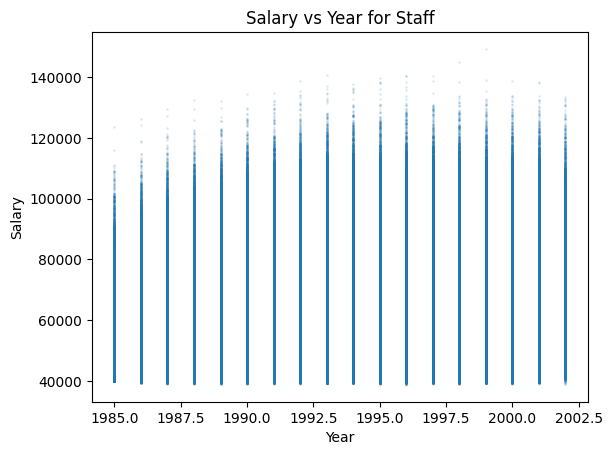

Learned parameters: slope (w) = 222.93, intercept (b) = -379782.91
Estimated Salary for a Staff in 2025: $71652.62


In [4]:
target_title = 'Staff'
df_target = df_full[df_full['title'] == target_title].copy()

# Prepare Data
# X: Year (derived from from_date or to_date). We use from_date year.
# y: Salary

df_target['year'] = df_target['from_date_salary'].dt.year
X_raw = df_target['year'].values
y_raw = df_target['salary'].values

# Visualization
plt.scatter(X_raw, y_raw, alpha=0.1, s=1)
plt.title(f"Salary vs Year for {target_title}")
plt.xlabel("Year")
plt.ylabel("Salary")
plt.show()

# Linear Regression: y = w*x + b
# We construct the design matrix A = [x, 1]
# Theta = (A.T A)^-1 A.T y

# Normalize X for numerical stability (optional but good practice, though normal equation handles small scale ok with 64bit)
# For simplicity and "Canonical" raw interpretation, we stick to [Year, 1].

# JAX Arrays
X = jnp.array(X_raw, dtype=jnp.float32)
y = jnp.array(y_raw, dtype=jnp.float32)

# Design Matrix which includes the intercept term (column of 1s)
A = jnp.vstack([X, jnp.ones_like(X)]).T

# Canonical Normal Equation: theta = (A^T A)^-1 A^T y
# Compute A^T A
ATA = A.T @ A
# Compute A^T y
ATy = A.T @ y

# Solve
theta = jnp.linalg.solve(ATA, ATy)

w, b = theta
print(f"Learned parameters: slope (w) = {w:.2f}, intercept (b) = {b:.2f}")

# Predict for 2025
year_target = 2025
salary_2025 = w * year_target + b

print(f"Estimated Salary for a {target_title} in 2025: ${salary_2025:.2f}")

## Exercise 2: Regularized Linear Regression

We are asked to implement the regularized version of the loss function (Ridge Regression):
$$ L(w) = \sum_{i=1}^{N} (y_i - x_i^T w)^2 + \lambda \sum_{i=1}^{d+1} w_i^2 $$

### Part (a): Gradient Derivation

To find the gradient $\nabla L(w)$, we differentiate $L(w)$ with respect to $w$.

Let $X$ be the design matrix of shape $(N, d+1)$ and $y$ be the target vector of shape $(N,)$.
The loss can be written in matrix form:
$$ L(w) = \|y - Xw\|^2 + \lambda \|w\|^2 $$
$$ L(w) = (y - Xw)^T (y - Xw) + \lambda w^T w $$

Expanding the first term:
$$ (y - Xw)^T (y - Xw) = y^T y - 2 w^T X^T y + w^T X^T X w $$
Differentiation with respect to $w$:
$$ \nabla (y^T y) = 0 $$
$$ \nabla (-2 w^T X^T y) = -2 X^T y $$
$$ \nabla (w^T X^T X w) = 2 X^T X w $$

Differentiating the regularization term:
$$ \nabla (\lambda w^T w) = 2 \lambda w $$

Combining these, the gradient is:
$$ \nabla L(w) = -2 X^T y + 2 X^T X w + 2 \lambda w $$
$$ \nabla L(w) = 2 [ X^T (Xw - y) + \lambda w ] $$

The update rule for Gradient Descent with learning rate $\alpha$ is:
$$ w_{t+1} = w_t - \alpha \nabla L(w_t) $$


Final Loss: 703455.9
Estimated Salary for a Staff in 2025 (Ridge, lambda=0.1): $77039.88


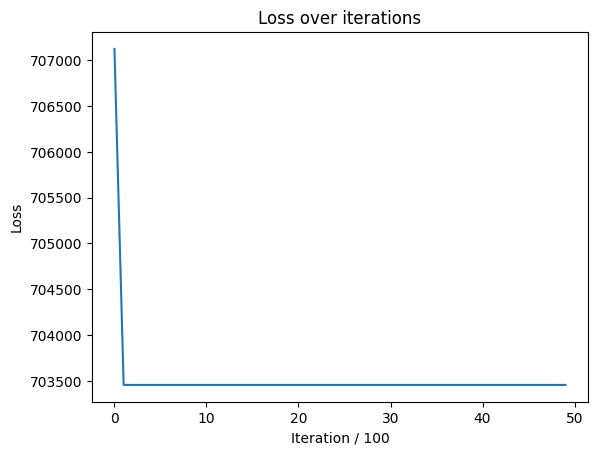

In [8]:
def loss_function(w, X, y, lam):
    """
    Computes the regularized loss.
    """
    residuals = y - jnp.dot(X, w)
    data_loss = jnp.sum(residuals ** 2)
    reg_loss = lam * jnp.sum(w ** 2)
    return data_loss + reg_loss

def gradient_manual(w, X, y, lam):
    """
    Computes the gradient manually derived in Part (a).
    grad = 2 * (X^T @ (X @ w - y) + lam * w)
    """
    N = X.shape[0]
    residuals = jnp.dot(X, w) - y
    # Gradient of data term: 2 * X.T @ residuals
    grad_data = 2 * jnp.dot(X.T, residuals)
    # Gradient of regularization term: 2 * lam * w
    grad_reg = 2 * lam * w
    return grad_data + grad_reg

def gradient_descent(X, y, lam, alpha, n_iterations):
    # Initialize weights randomly
    d = X.shape[1]
    w = jax.random.normal(jax.random.PRNGKey(0), (d,)) * 0.01
    
    loss_history = []
    
    for i in range(n_iterations):
        grad = gradient_manual(w, X, y, lam)
        w = w - alpha * grad
        
        if i % 100 == 0:
            l = loss_function(w, X, y, lam)
            loss_history.append(l)
            
    return w, loss_history

# Part (c): Answer the problem from Exercise 1 using this new model.
# We need to normalize our features for Gradient Descent to work effectively.
# X is [Year], y is Salary.

# Standardize X and y
year_mean = jnp.mean(X_raw)
year_std = jnp.std(X_raw)
salary_mean = jnp.mean(y_raw)
salary_std = jnp.std(y_raw)

X_norm = (X_raw - year_mean) / year_std
y_norm = (y_raw - salary_mean) / salary_std

# Add bias term to X_norm
X_design = jnp.vstack([X_norm, jnp.ones_like(X_norm)]).T
# Convert y to JAX array
y_train = jnp.array(y_norm)

# Hyperparameters
lam = 0.1 # Example lambda
alpha = 1e-7 # Learning rate (adjusted for Sum of Squares Loss with large N)
n_iterations = 5000

w_ridge, history = gradient_descent(X_design, y_train, lam, alpha, n_iterations)

print("Final Loss:", history[-1])

# Predict for 2025
year_target = 2025
year_target_norm = (year_target - year_mean) / year_std

# Prediction in normalized space
# w_ridge = [weight_feature, weight_bias]
pred_norm = w_ridge[0] * year_target_norm + w_ridge[1]

# Denormalize
pred_salary = pred_norm * salary_std + salary_mean
print(f"Estimated Salary for a {target_title} in 2025 (Ridge, lambda={lam}): ${pred_salary:.2f}")

# Plot Loss
plt.plot(history)
plt.title("Loss over iterations")
plt.xlabel("Iteration / 100")
plt.ylabel("Loss")
plt.show()


In [7]:
print(f"Number of samples: {X_raw.shape[0]}")
# Suggest alpha
print(f"Suggested alpha: {1.0 / X_raw.shape[0]}")


Number of samples: 710208
Suggested alpha: 1.4080382085248265e-06


In [9]:
# Part (d): Grid Search for Lambda
# We will use simple Cross-Validation or just Train/Validation split to find best lambda.
# Since the dataset is large, let's just do a 80-20 split.

# Shuffle and split
folder_indices = jax.random.permutation(jax.random.PRNGKey(42), len(y_train))
split_idx = int(len(y_train) * 0.8)
train_idx, val_idx = folder_indices[:split_idx], folder_indices[split_idx:]

X_train, X_val = X_design[train_idx], X_design[val_idx]
y_t, y_v = y_train[train_idx], y_train[val_idx]

lambda_values = [0.0, 0.01, 0.1, 1.0, 10.0, 100.0]
best_lam = None
best_val_loss = float('inf')
results = []

alpha = 1e-7  # Use the same small alpha
n_iterations = 3000

print(f"Grid Search for Lambda...")
for lam in lambda_values:
    w_opt, _ = gradient_descent(X_train, y_t, lam, alpha, n_iterations)
    
    # Validation Loss (MSE) - omitting regularization term for fair comparison of fit, 
    # but strictly speaking validation loss usually is just MSE.
    residuals = y_v - jnp.dot(X_val, w_opt)
    val_mse = jnp.mean(residuals ** 2)
    
    results.append((lam, val_mse))
    print(f"Lambda: {lam}, Validation MSE: {val_mse:.5f}")
    
    if val_mse < best_val_loss:
        best_val_loss = val_mse
        best_lam = lam

print(f"Best Lambda: {best_lam}")

# Retrain with best lambda on full set
w_best, _ = gradient_descent(X_design, y_train, best_lam, alpha, n_iterations)

# Predict for 2025
pred_norm_best = w_best[0] * year_target_norm + w_best[1]
pred_salary_best = pred_norm_best * salary_std + salary_mean
print(f"Estimated Salary for a {target_title} in 2025 (Best Ridge, lambda={best_lam}): ${pred_salary_best:.2f}")


Grid Search for Lambda...
Lambda: 0.0, Validation MSE: 0.99281
Lambda: 0.01, Validation MSE: 0.99281
Lambda: 0.1, Validation MSE: 0.99281
Lambda: 1.0, Validation MSE: 0.99281
Lambda: 10.0, Validation MSE: 0.99281
Lambda: 100.0, Validation MSE: 0.99281
Best Lambda: 0.0
Estimated Salary for a Staff in 2025 (Best Ridge, lambda=0.0): $77039.88


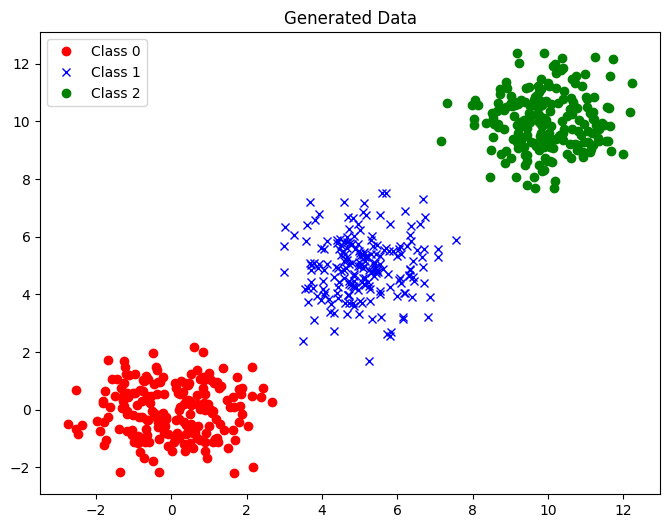

X shape: (2, 600)
Y shape: (600,)


In [10]:
# ---------------------------------------------------------
# Exercise 3: Logistic Regression with Cholesky Decomposition
# ---------------------------------------------------------

class Tools:
    def __init__(self):
        self.key = jax.random.PRNGKey(0)
    
    def GenerateData(self, n_samples: int, n_classes: int, dim: int):
        Total_Data = [] 
        Total_Y = []
        for idx in range(n_classes):
            keys = jax.random.split(self.key, 1)
            # Example data generation from the notebook
            # Shift each class by idx * 5
            X = jax.random.normal(keys[0], (dim, n_samples)) + idx * 5 * jnp.ones((dim, 1))
            Y = idx * jnp.ones(n_samples)
            Total_Data.append(X)
            Total_Y.append(Y)
            
            # Update key for next iteration
            self.key, _ = jax.random.split(self.key)
            
        return jnp.hstack(Total_Data), jnp.hstack(Total_Y)

    @staticmethod
    def plot_classes(X, Y, n_classes):
        symbols = ['ro', 'bx', 'go', 'rx']
        plt.figure(figsize=(8, 6))
        for idx in range(n_classes):
            mask = idx == Y
            X_p = X[:, mask]
            plt.plot(X_p[0,:], X_p[1,:], symbols[idx % len(symbols)], label=f'Class {idx}')
        plt.legend()
        plt.title("Generated Data")
        plt.show()

# Generate Data
tools = Tools()
n_samples = 200
n_classes = 3
dim = 2
X_log, Y_log = tools.GenerateData(n_samples=n_samples, n_classes=n_classes, dim=dim)
tools.plot_classes(X_log, Y_log, n_classes)

print("X shape:", X_log.shape)
print("Y shape:", Y_log.shape)


Training Classic Model...
Classic converged at iter 17
Training Cholesky Model...
Cholesky converged at iter 17


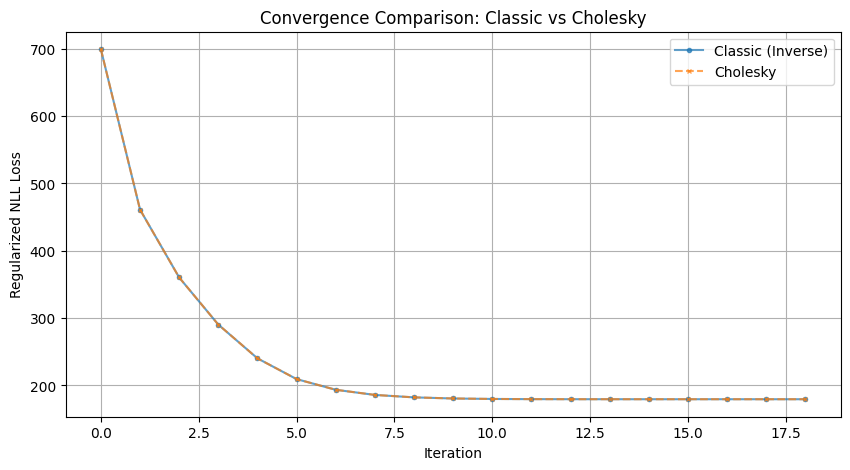

Final Accuracy (Cholesky model): 99.83%


In [12]:
from functools import partial

class Logistic_Regression:
    def __init__(self, key):
        self.key = key
        self.W = None
        self.sh = None
        
    @staticmethod
    @jax.jit
    def logistic_exp(W, X):
        return jnp.exp(jnp.dot(W, X))
        
    @staticmethod
    @jax.jit
    def logistic_sum(exTerms):
        temp = jnp.sum(exTerms, axis=0)
        n = temp.shape[0]
        return jnp.reshape(1.0 + temp, (1, n))
        
    @staticmethod
    @jax.jit
    def logit_matrix(Terms, sum_terms):
        divisor = 1 / sum_terms
        n, _ = Terms.shape
        replicate = jnp.repeat(divisor, repeats=n, axis=0)
        logits = Terms * replicate
        return jnp.vstack([logits, divisor])
        
    @partial(jax.jit, static_argnums=(0,))
    def model(self, W, X, Y_hot, lam=1e-4):
        W = jnp.reshape(W, self.sh)
        # Add small epsilon to avoid NaN in log
        terms = self.logistic_exp(W, X)
        sum_terms = self.logistic_sum(terms)
        matrix = self.logit_matrix(terms, sum_terms)
        
        # Cross Entropy Loss
        nll = -jnp.sum(jnp.sum(jnp.log(matrix + 1e-10) * Y_hot, axis=0), axis=0)
        
        # L2 Regularization
        reg = lam * jnp.sum(W**2)
        return nll + reg
    
    @staticmethod
    def one_hot(Y):
        numclasses = len(jnp.unique(Y))
        return jnp.transpose(jax.nn.one_hot(Y, num_classes=numclasses))
        
    @staticmethod
    def augment_x(X):
        N = X.shape[1]
        return jnp.vstack([X, jnp.ones((1, N))])
        
    def generate_w(self, k_classes, dim):
        key = jax.random.PRNGKey(0)
        return jax.random.normal(key, (k_classes, dim)) * 0.01

    def fit(self, X, Y, method='classic', alpha=0.1, tol=1e-4, max_iter=200, lam=1e-4):
        nclasses = len(jnp.unique(Y))
        X_aug = self.augment_x(X)
        dim = X_aug.shape[0]
        
        # We model K-1 classes, the K-th is implied by sum=1
        if self.W is None or self.W.shape != (nclasses-1, dim):
            W_init = self.generate_w(nclasses-1, dim)
        else:
             W_init = self.W
             
        self.sh = W_init.shape
        Y_hot = self.one_hot(Y)
        
        # Dispatch method
        if method == 'classic':
            return self.classic_model(W_init, X_aug, Y_hot, alpha, tol, max_iter, lam)
        elif method == 'cholesky':
            return self.cholesky_model(W_init, X_aug, Y_hot, alpha, tol, max_iter, lam)
        else:
            raise ValueError("Unknown method")

    def classic_model(self, W, X, Y_hot, alpha, tol, max_iter, lam):
        loss_hist = []
        W_flat = jnp.ravel(W)
        loss = self.model(W_flat, X, Y_hot, lam)
        loss_hist.append(loss)
        
        for i in range(max_iter):
            Grad = jax.grad(self.model)(W_flat, X, Y_hot, lam)
            Hessian = jax.hessian(self.model)(W_flat, X, Y_hot, lam)
            
            try:
                inv_H = jnp.linalg.inv(Hessian)
                update = jnp.dot(inv_H, Grad)
            except:
                inv_H = jnp.linalg.pinv(Hessian)
                update = jnp.dot(inv_H, Grad)
            
            W_flat = W_flat - alpha * update
            
            new_loss = self.model(W_flat, X, Y_hot, lam)
            loss_hist.append(new_loss)
            
            if jnp.abs(loss - new_loss) < tol:
                print(f"Classic converged at iter {i}")
                break
            loss = new_loss
            
        self.W = jnp.reshape(W_flat, self.sh)
        return loss_hist

    def cholesky_model(self, W, X, Y_hot, alpha, tol, max_iter, lam):
        loss_hist = []
        W_flat = jnp.ravel(W)
        loss = self.model(W_flat, X, Y_hot, lam)
        loss_hist.append(loss)
        
        for i in range(max_iter):
            Grad = jax.grad(self.model)(W_flat, X, Y_hot, lam)
            Hessian = jax.hessian(self.model)(W_flat, X, Y_hot, lam)
            
            try:
                # Cholesky requires PD. Regularization makes it PD.
                L = jax.linalg.cholesky(Hessian)
                y = jax.scipy.linalg.solve_triangular(L, Grad, lower=True)
                update = jax.scipy.linalg.solve_triangular(L.T, y, lower=False)
            except:
                # Fallback
                inv_H = jnp.linalg.pinv(Hessian)
                update = jnp.dot(inv_H, Grad)

            W_flat = W_flat - alpha * update
            
            new_loss = self.model(W_flat, X, Y_hot, lam)
            loss_hist.append(new_loss)
            
            if jnp.abs(loss - new_loss) < tol:
                print(f"Cholesky converged at iter {i}")
                break
            loss = new_loss
            
        self.W = jnp.reshape(W_flat, self.sh)
        return loss_hist

    def estimate(self, X):
        X_aug = self.augment_x(X)
        terms = self.logistic_exp(self.W, X_aug)
        sum_terms = self.logistic_sum(terms)
        matrix = self.logit_matrix(terms, sum_terms)
        return jnp.argmax(matrix, axis=0)

model = Logistic_Regression(jax.random.PRNGKey(42))

print("Training Classic Model...")
model.W = None # Reset
hist_classic = model.fit(X_log, Y_log, method='classic', alpha=0.5, max_iter=100, lam=1.0)

print("Training Cholesky Model...")
model.W = None # Reset
hist_cholesky = model.fit(X_log, Y_log, method='cholesky', alpha=0.5, max_iter=100, lam=1.0)

# Compare Convergence
plt.figure(figsize=(10, 5))
plt.plot(hist_classic, label='Classic (Inverse)', marker='o', markersize=3, alpha=0.7)
plt.plot(hist_cholesky, label='Cholesky', linestyle='--', marker='x', markersize=3, alpha=0.7)
plt.xlabel('Iteration')
plt.ylabel('Regularized NLL Loss')
plt.title('Convergence Comparison: Classic vs Cholesky')
plt.legend()
plt.grid(True)
plt.show()

# Final accuracy check
Y_pred = model.estimate(X_log)
acc = jnp.mean(Y_pred == Y_log)
print(f"Final Accuracy (Cholesky model): {acc:.2%}")
